# BinMetricsRegression

Регрессионный взгляд на scalar-метрики из `BinMetrics`: сравниваем каждую метрику не с бинарным success/fail, а напрямую с `drop = conf_clean - conf_patch`.

Ноутбук использует тот же COCO_people attack cache и SegmentIG-only success/failure cache. Новые таблицы похожести тоже кэшируются.

## Setup и загрузка общего cache

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd
from IPython.display import display

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    load_segmentig_success_failure_rows,
    make_coco_people_patch_success_experiment,
)
from patch_success_analysis import regression_metrics

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment()
print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
cache = exp.build_or_load_cache(force=False)
print(cache.to_summary())

cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
{'cache_key': 'e91cdfc4a2c4e20d', 'config': {'dataset_path': ['../datasets/COCO_people'], 'patch_path': '../data/patch.png', 'model_path': 'yolo11s.pt', 'output_dir': 'new_experiments/outputs/patch_success_analysis', 'imgsz': 640, 'device': 'mps', 'target_class_name': 'person', 'conf': 0.01, 'success_thresh': 0.3, 'seed': 17, 'pool_size': 7200, 'n_success': 3000, 'n_fail': 3000, 'apply_patch_after_letterbox': True, 'patch_xy': (0, 0)}, 'balanced_total': 5650, 'balanced_success': 3000, 'balanced_fail': 2650, 'pool_total': 7200, 'pool_success': 4550, 'pool_fail': 2650, 'pool_failed_images': 0, 'failed_paths': []}


## Загрузка scalar-метрик из BinMetrics cache

In [2]:
force_success_failure_metrics_recompute = False

sf, rows_df, quality_df = load_segmentig_success_failure_rows(
    exp,
    force=force_success_failure_metrics_recompute,
)

print(f"segmentig success/failure cache: {sf.get('cache_path')}")
print(f"loaded_from_cache={sf.get('loaded_from_cache')}")
print(f"examples={len(rows_df)}, binary metrics={len(quality_df)}")
display(rows_df[['path', 'success', 'drop', 'conf_clean', 'conf_patch']].head())
display(quality_df.head(10))

segmentig success/failure cache: new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_3362be6645634ce2.pkl
loaded_from_cache=True
examples=5646, binary metrics=207


,path,success,drop,conf_clean,conf_patch
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.876263,0.000000
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.926853,0.557409
4,../datasets/COCO_people/04480_train2017_image1...,False,0.004722,0.900169,0.895448


,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
61,segmentig_hand_rank_ratio_top5_top25,0.669002,0.640985,0.228035,1,new_experiments/outputs/patch_success_analysis...
7,segmentig_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
72,segmentig_hand_overlap_top5_delta_in_topA,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
55,segmentig_hand_rank_top5_delta_frac,0.667376,0.639391,0.056406,1,new_experiments/outputs/patch_success_analysis...
5,segmentig_align_top_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
71,segmentig_hand_overlap_top5_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
56,segmentig_hand_rank_top6_delta_frac,0.666895,0.637442,0.064968,1,new_experiments/outputs/patch_success_analysis...
19,segmentig_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,new_experiments/outputs/patch_success_analysis...
74,segmentig_hand_overlap_top10_jaccard,0.659817,0.636026,0.054759,1,new_experiments/outputs/patch_success_analysis...
21,segmentig_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,new_experiments/outputs/patch_success_analysis...


## Корреляции и похожесть с drop

Считаем для каждой численной scalar-метрики:

- `pearson`: линейная корреляция с `drop`;
- `spearman`, `kendall`: ранговая/монотонная связь;
- `linear_r2`: насколько одна метрика после линейной калибровки объясняет `drop`;
- `calibrated_mae`, `calibrated_rmse`, `calibrated_nrmse`: ошибка после линейной калибровки в шкалу `drop`;
- `mutual_info`: нелинейная зависимость без предположения о монотонности;
- `distance_corr`: нелинейная distance correlation на фиксированном subsample;
- `main_score`: усредненный score по `abs_spearman`, `abs_pearson`, `abs_kendall`, `linear_r2`, `mutual_info_norm`, `distance_corr` и inverse-error score.

In [3]:
force_drop_regression_similarity_recompute = False

regression_result = regression_metrics.compute_or_load_drop_regression_similarity(
    exp,
    rows_df,
    target_col='drop',
    force=force_drop_regression_similarity_recompute,
)
similarity_df = regression_result['similarity_df']

print(f"drop regression similarity cache: {regression_result['cache_path']}")
print(f"loaded_from_cache={regression_result['loaded_from_cache']}")
print(f"examples={regression_result['n_rows']}, metrics={regression_result['n_metrics']}")

display(similarity_df)

drop regression similarity cache: new_experiments/outputs/patch_success_analysis/cache/drop_regression_similarity_dfef1e5f42b497c3.pkl
loaded_from_cache=False
examples=5646, metrics=209


,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,segmentig_delta_energy_importance_bins_top10_exp,5646,1.0,0.261860,0.267941,0.187063,0.261860,0.267941,0.187063,0.129335,...,0.339241,12.447714,-0.069903,0.068570,0.285943,0.327375,0.965106,0.991017,0.508878,0.361163
1,segmentig_hand_rank_top10_delta_frac,5646,1.0,0.254346,0.260877,0.181974,0.254346,0.260877,0.181974,0.125588,...,0.339241,7.383584,-0.329880,0.064692,0.286598,0.328056,0.967113,0.962303,0.508359,0.353219
2,segmentig_hand_rank_top6_delta_frac,5646,1.0,0.261970,0.269135,0.187712,0.261970,0.269135,0.187712,0.118856,...,0.339241,7.531546,-0.082172,0.068628,0.285544,0.327365,0.965076,0.910726,0.508886,0.351065
3,segmentig_delta_energy_importance_bins_top50_exp,5646,1.0,0.245350,0.254586,0.176419,0.245350,0.254586,0.176419,0.127350,...,0.339241,8.927102,-0.899512,0.060197,0.288132,0.328843,0.969434,0.975810,0.507760,0.350628
4,segmentig_hand_overlap_top10_delta_in_topA,5646,1.0,0.244556,0.249923,0.173529,0.244556,0.249923,0.173529,0.127560,...,0.339241,7.001472,-0.299982,0.059808,0.288078,0.328911,0.969635,0.977420,0.507708,0.349290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,segmentig_delta_energy_importance_binfrac_047,5646,1.0,0.032647,0.037596,0.024766,0.032647,0.037596,0.024766,0.000000,...,0.339241,11.774146,0.302562,0.001066,0.305462,0.339030,0.999467,0.000000,0.500133,0.094554
205,segmentig_delta_energy_importance_binfrac_044,5646,1.0,-0.013535,-0.032079,-0.021438,0.013535,0.032079,0.021438,0.003041,...,0.339241,-3.262036,0.478765,0.000183,0.305746,0.339180,0.999908,0.023302,0.500023,0.094524
206,segmentig_delta_energy_importance_binfrac_078,5646,1.0,-0.035065,-0.032882,-0.021955,0.035065,0.032882,0.021955,0.000000,...,0.339241,-14.427333,0.577469,0.001230,0.305268,0.339003,0.999385,0.000000,0.500154,0.092971
207,segmentig_delta_energy_importance_binfrac_067,5646,1.0,-0.032327,-0.021409,-0.014249,0.032327,0.021409,0.014249,0.000000,...,0.339241,-13.199286,0.534760,0.001045,0.305578,0.339034,0.999477,0.000000,0.500131,0.086970


## Все метрики графиками

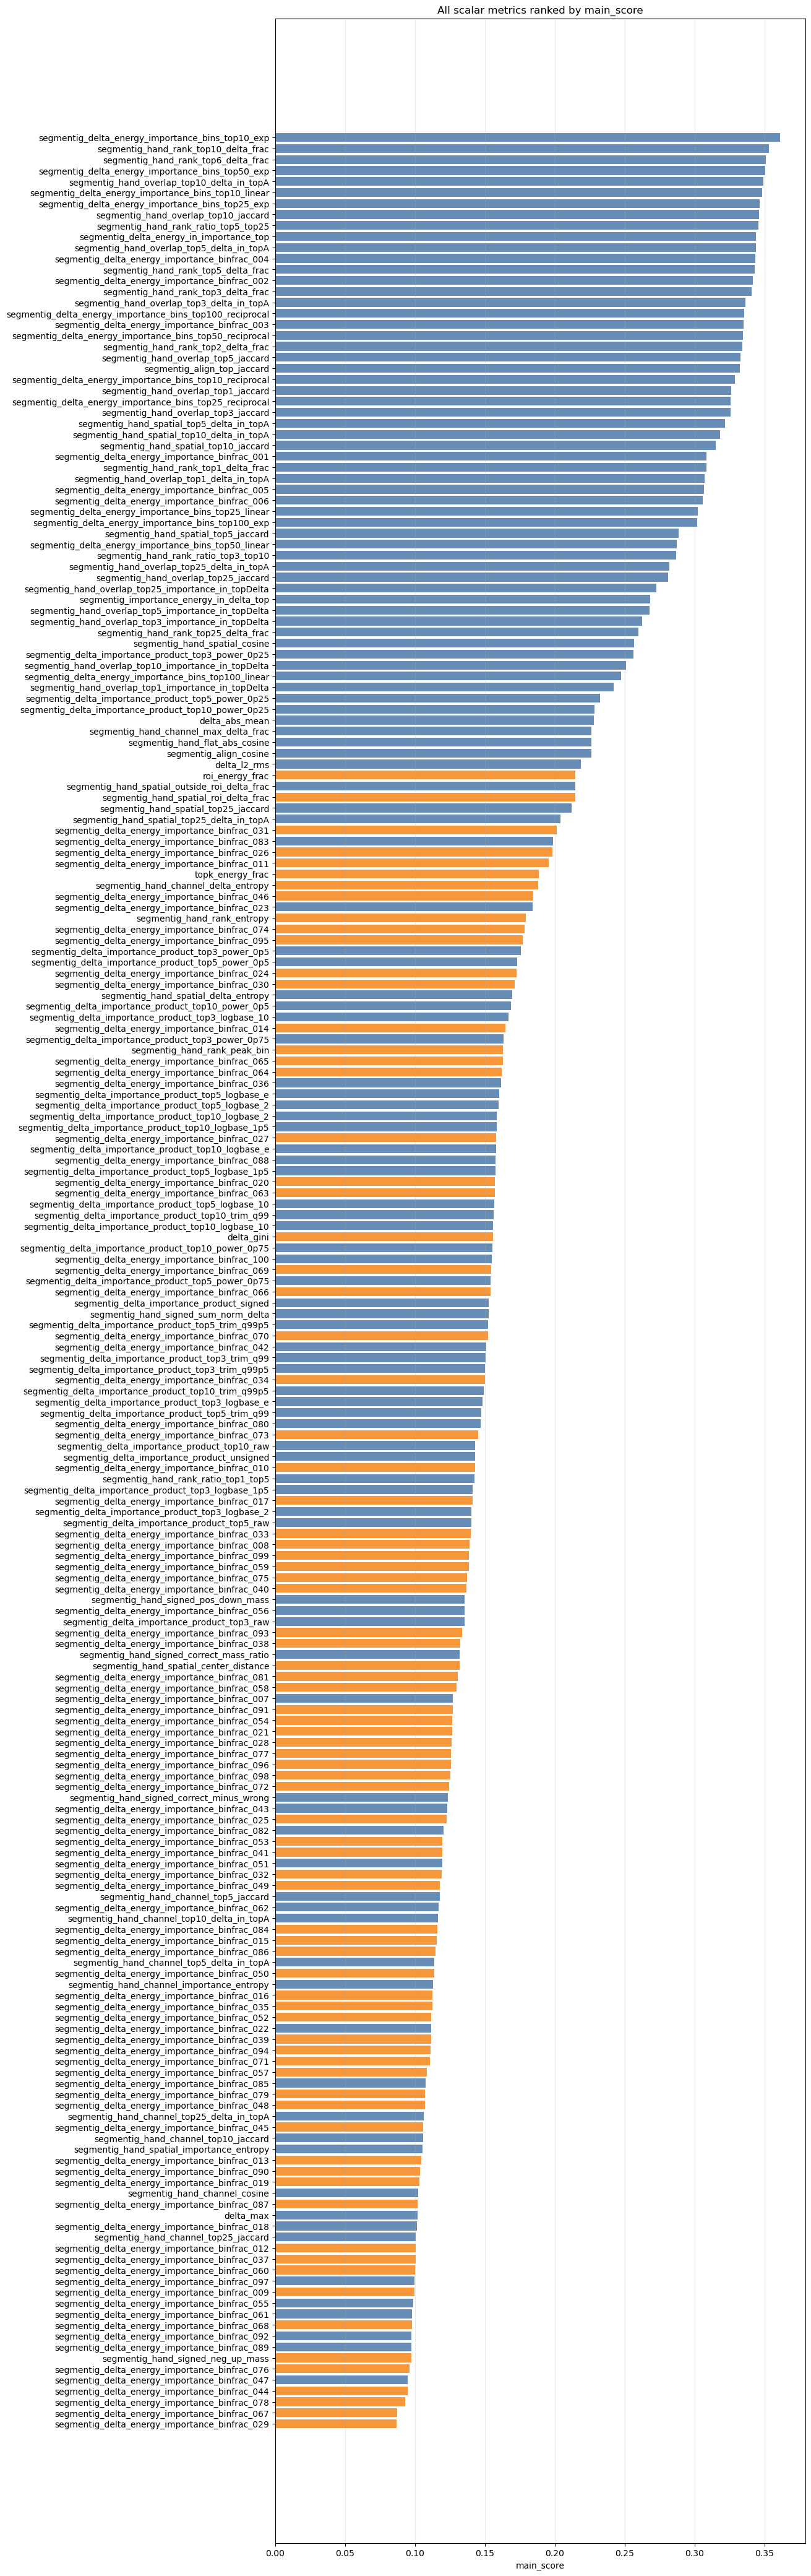

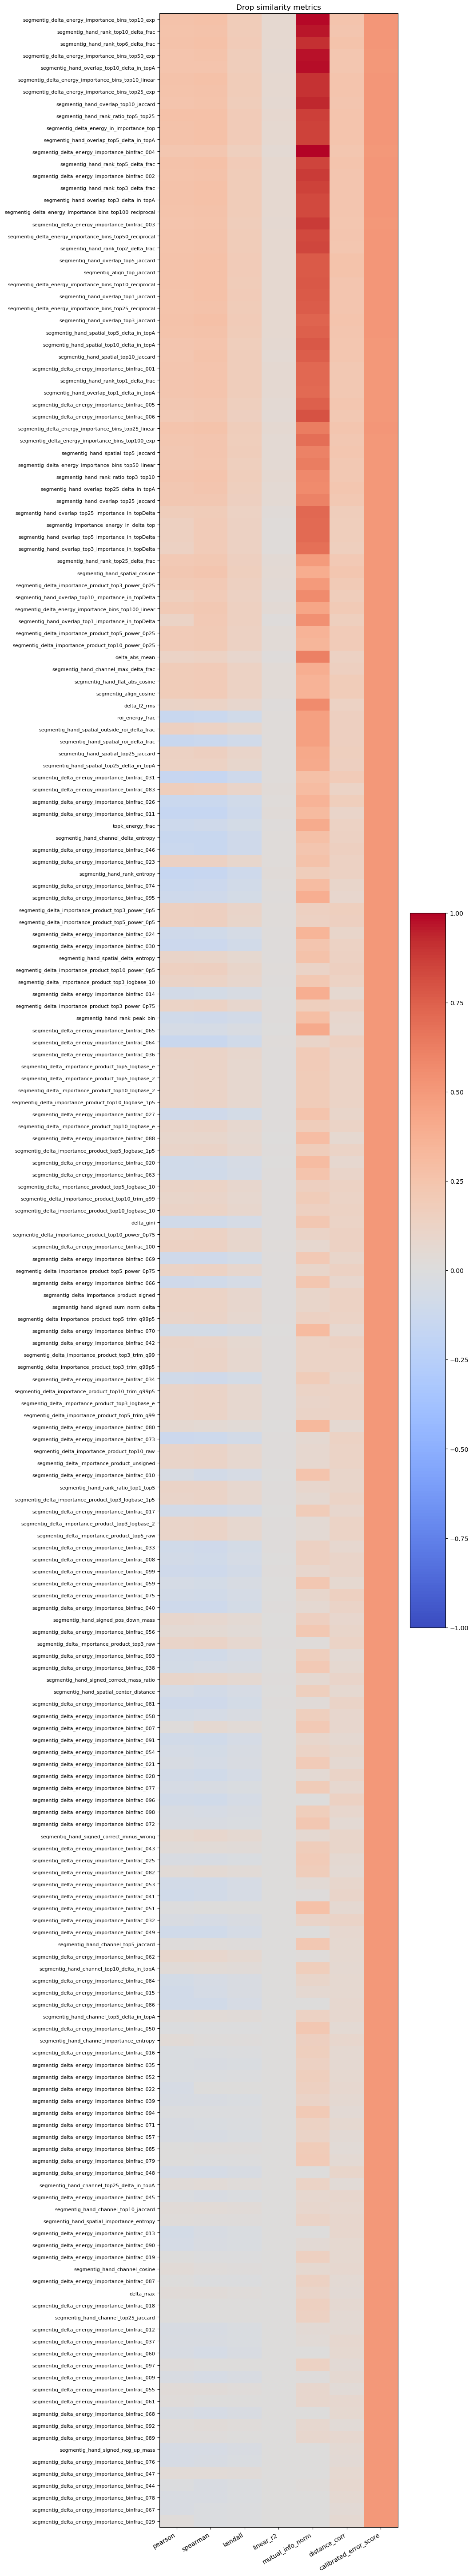

In [4]:
import matplotlib.pyplot as plt

fig = regression_metrics.plot_similarity_score_bars(similarity_df, score_col='main_score')
plt.show()

fig = regression_metrics.plot_similarity_heatmap(similarity_df)
plt.show()

## Лучшие метрики

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
0,segmentig_delta_energy_importance_bins_top10_exp,5646,1.0,0.261860,0.267941,0.187063,0.261860,0.267941,0.187063,0.129335,...,0.339241,12.447714,-0.069903,0.068570,0.285943,0.327375,0.965106,0.991017,0.508878,0.361163
1,segmentig_hand_rank_top10_delta_frac,5646,1.0,0.254346,0.260877,0.181974,0.254346,0.260877,0.181974,0.125588,...,0.339241,7.383584,-0.329880,0.064692,0.286598,0.328056,0.967113,0.962303,0.508359,0.353219
2,segmentig_hand_rank_top6_delta_frac,5646,1.0,0.261970,0.269135,0.187712,0.261970,0.269135,0.187712,0.118856,...,0.339241,7.531546,-0.082172,0.068628,0.285544,0.327365,0.965076,0.910726,0.508886,0.351065
3,segmentig_delta_energy_importance_bins_top50_exp,5646,1.0,0.245350,0.254586,0.176419,0.245350,0.254586,0.176419,0.127350,...,0.339241,8.927102,-0.899512,0.060197,0.288132,0.328843,0.969434,0.975810,0.507760,0.350628
4,segmentig_hand_overlap_top10_delta_in_topA,5646,1.0,0.244556,0.249923,0.173529,0.244556,0.249923,0.173529,0.127560,...,0.339241,7.001472,-0.299982,0.059808,0.288078,0.328911,0.969635,0.977420,0.507708,0.349290
5,segmentig_delta_energy_importance_bins_top10_l...,5646,1.0,0.261631,0.268203,0.187147,0.261631,0.268203,0.187147,0.117378,...,0.339241,9.346709,-0.138714,0.068451,0.285642,0.327396,0.965168,0.899398,0.508862,0.348580
6,segmentig_delta_energy_importance_bins_top25_exp,5646,1.0,0.257021,0.264682,0.184237,0.257021,0.264682,0.184237,0.117599,...,0.339241,9.747040,-0.347488,0.066060,0.286386,0.327816,0.966406,0.901095,0.508542,0.346406
7,segmentig_hand_overlap_top10_jaccard,5646,1.0,0.247775,0.253210,0.176385,0.247775,0.253210,0.176385,0.122232,...,0.339241,9.332327,-0.108370,0.061392,0.287426,0.328634,0.968818,0.936590,0.507919,0.346301
8,segmentig_hand_rank_ratio_top5_top25,5646,1.0,0.268389,0.269266,0.188152,0.268389,0.269266,0.188152,0.112661,...,0.339241,2.709007,-0.197742,0.072033,0.284622,0.326766,0.963311,0.863256,0.509344,0.345638
9,segmentig_delta_energy_in_importance_top,5646,1.0,0.263398,0.269800,0.187943,0.263398,0.269800,0.187943,0.112119,...,0.339241,8.503631,-0.072635,0.069379,0.285466,0.327233,0.964687,0.859098,0.508987,0.344018


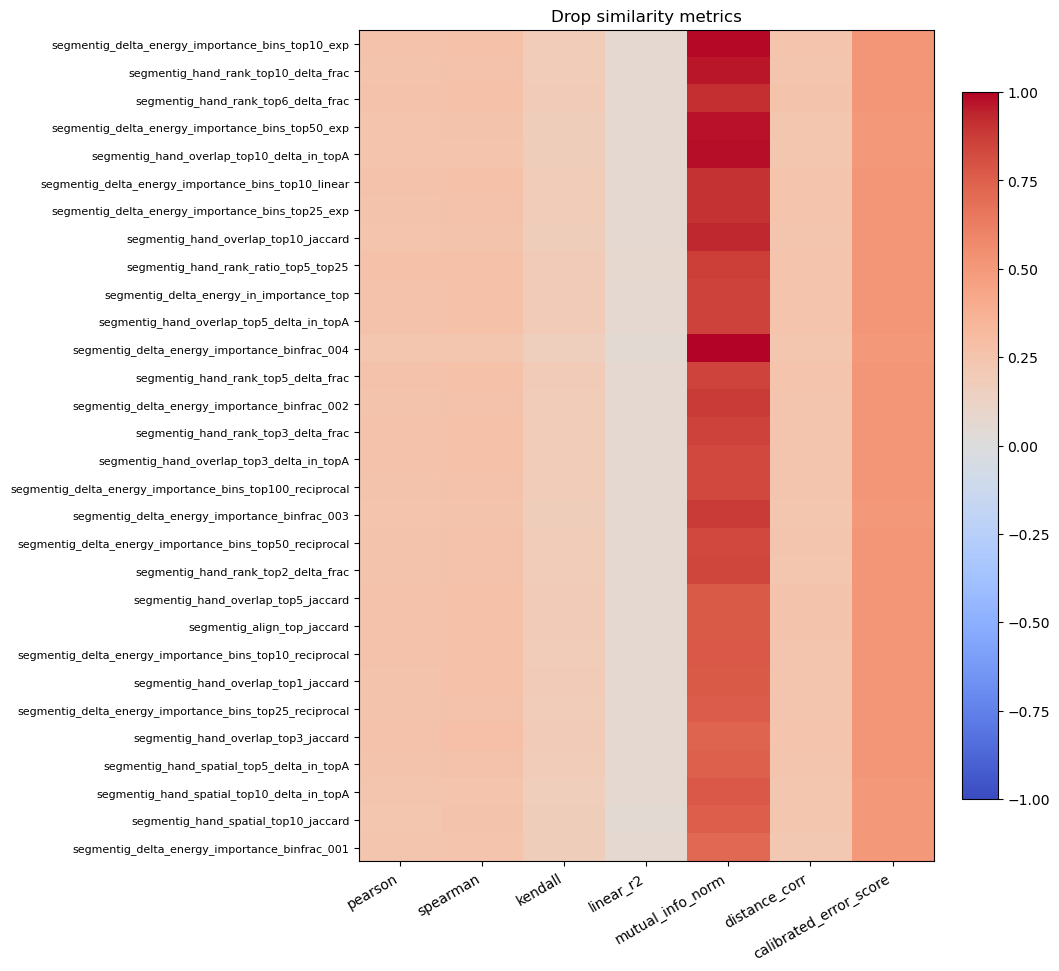

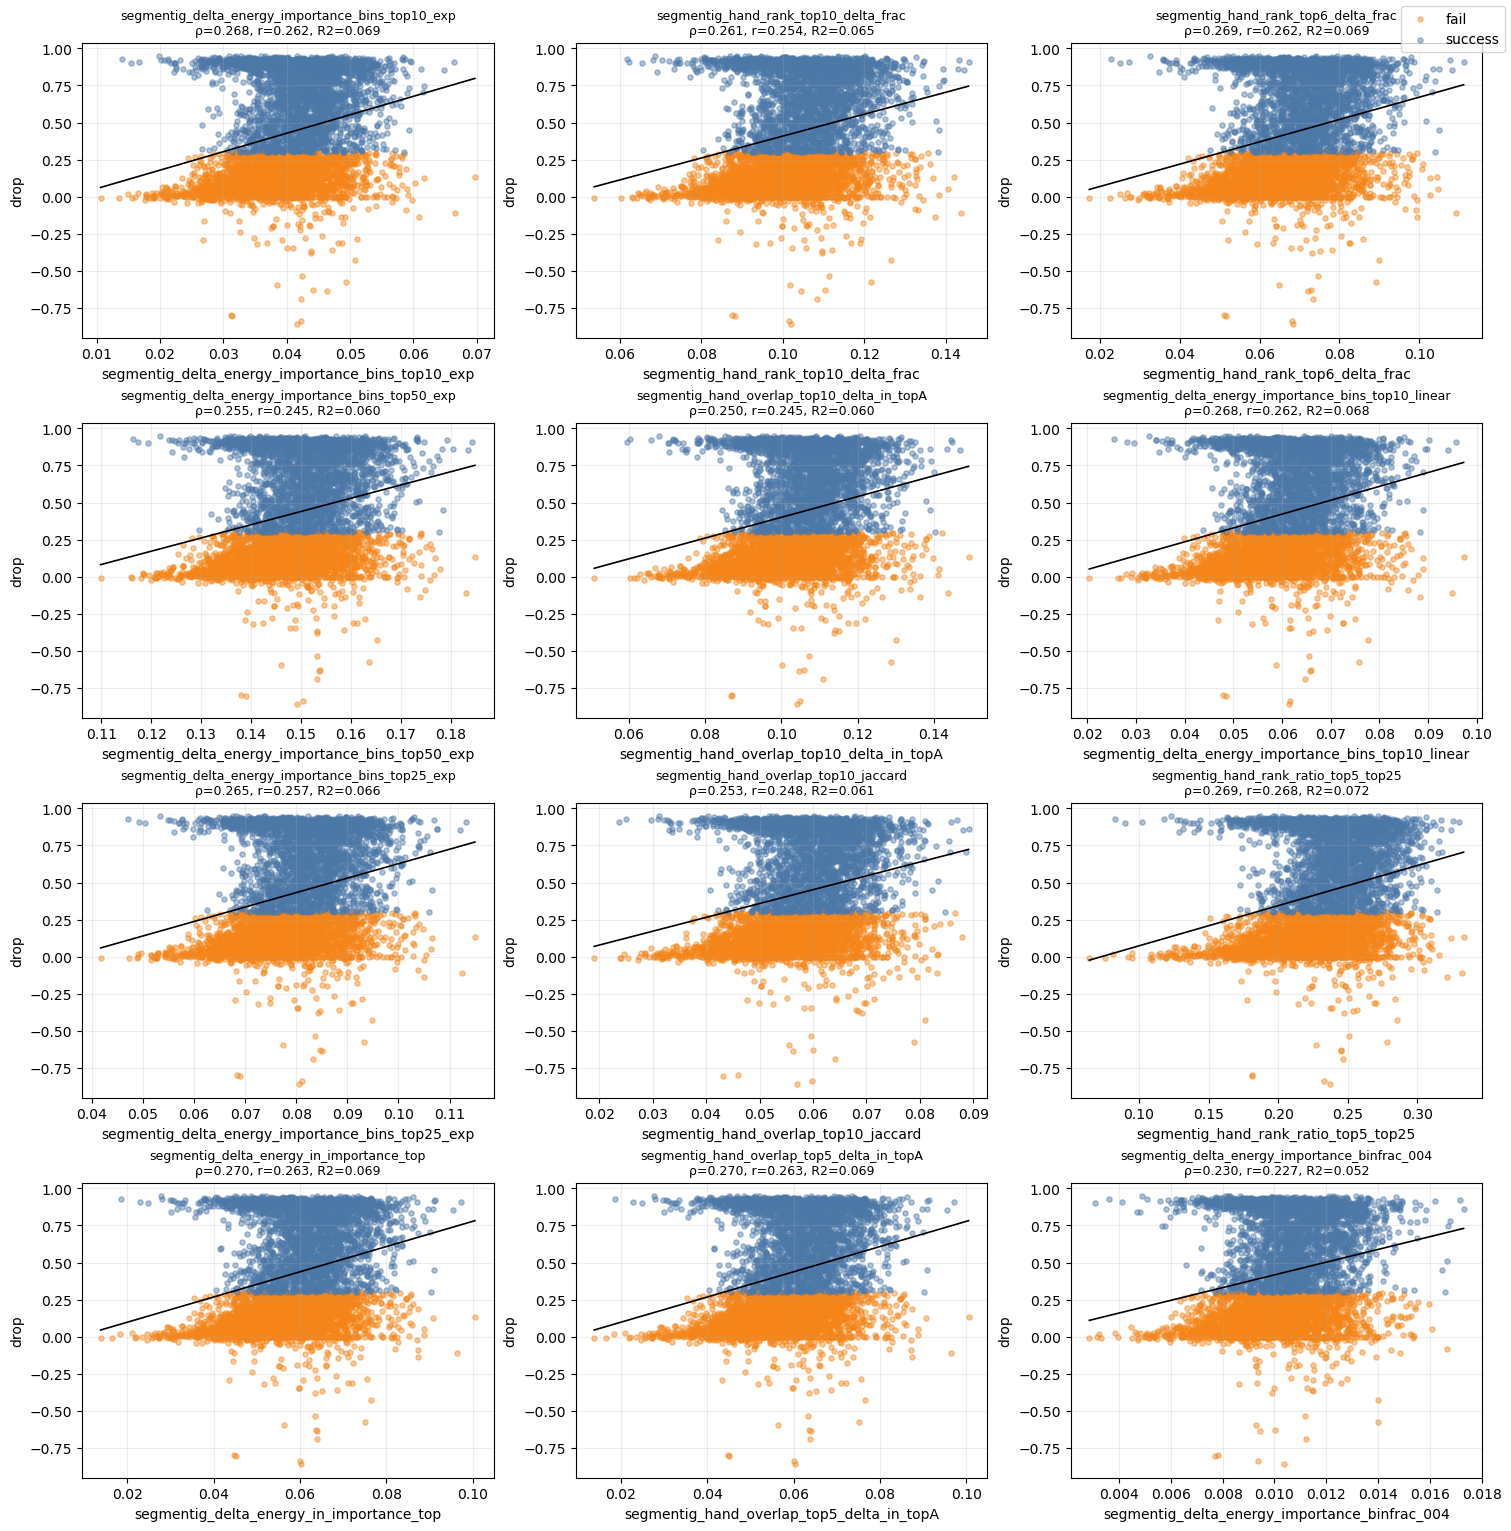

In [5]:
top_n = 30
best_similarity_df = similarity_df.head(top_n).copy()
display(best_similarity_df)

fig = regression_metrics.plot_similarity_heatmap(best_similarity_df, top_n=top_n)
plt.show()

fig = regression_metrics.plot_top_metric_scatter(rows_df, similarity_df, target_col='drop', top_n=12)
plt.show()

## Лучшие по отдельным критериям

In [ ]:
criteria = [
    'abs_spearman',
    'abs_pearson',
    'abs_kendall',
    'linear_r2',
    'mutual_info',
]

leaderboards = []
for criterion in criteria:
    cols = [
        'metric',
        criterion,
        'pearson',
        'spearman',
        'kendall',
        'linear_r2',
        'mutual_info',
        'calibrated_nrmse',
        'main_score',
    ]
    sub = similarity_df.sort_values(criterion, ascending=False)[cols].head(20).copy()
    sub.insert(0, 'criterion', criterion)
    leaderboards.append(sub)

leaderboards_df = pd.concat(leaderboards, ignore_index=True)
display(leaderboards_df)

fig, axes = plt.subplots(len(criteria), 1, figsize=(13, 4.2 * len(criteria)), constrained_layout=True)
for ax, criterion in zip(axes, criteria):
    sub = similarity_df.sort_values(criterion, ascending=True).tail(20)
    ax.barh(sub['metric'], sub[criterion], color='#4C78A8')
    ax.set_title(f'Top metrics by {criterion}')
    ax.set_xlabel(criterion)
    ax.grid(axis='x', alpha=0.25)
plt.show()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

: 

## Связь с бинарным качеством

In [ ]:
binary_cols = ['metric', 'roc_auc', 'best_accuracy', 'best_direction']
comparison_df = similarity_df.merge(
    quality_df[binary_cols],
    on='metric',
    how='left',
)
display(comparison_df.sort_values('main_score', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(comparison_df['best_accuracy'], comparison_df['main_score'], alpha=0.7)
axes[0].set_xlabel('success/fail best accuracy')
axes[0].set_ylabel('drop similarity main_score')
axes[0].set_title('Binary accuracy vs drop similarity')
axes[0].grid(alpha=0.25)

axes[1].scatter(comparison_df['roc_auc'], comparison_df['abs_spearman'], alpha=0.7, color='#F58518')
axes[1].set_xlabel('success/fail ROC-AUC')
axes[1].set_ylabel('|Spearman(drop, metric)|')
axes[1].set_title('Binary ROC-AUC vs rank correlation with drop')
axes[1].grid(alpha=0.25)
plt.show()